# 1. Comparative Analysis of Option Pricing Models: BSM vs. CRR

## Project Overview
This project implements and compares the two fundamental pillars of modern option pricing: the **Black-Scholes-Merton (BSM)** continuous-time model and the **Cox-Ross-Rubinstein (CRR)** discrete-time binomial model.

Using **Apple Inc. (AAPL)** as our underlying asset and live macroeconomic data from the **FRED**, we aim to:
1.  Build a robust **Object-Oriented Programming (OOP)** architecture to price European options.
2.  Empirically demonstrate the **convergence** of discrete numerical methods toward analytical solutions.
3.  Critically evaluate model assumptions (Normality and Stationarity) against real-world market data.

## Technical Stack
* **Data Acquisition:** `yfinance` for equity data and `fredpy` for risk-free rates.
* **Architecture:** Class-based inheritance with custom Python decorators for performance monitoring.
* **Validation:** Statistical testing via Augmented Dickey-Fuller (ADF) and Normality analysis (QQ-Plots).

In [1]:
# ==========================================
# INSTALLATION OF LIBRARIES
# ==========================================
%pip install pandas 
%pip install numpy 
%pip install matplotlib 
%pip install scipy 
%pip install statsmodels 
%pip install yfinance
%pip install datetime
%pip install fredpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ==========================================
# IMPORT OF LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import fredpy as fp

print("Libraries successfully imported.")

Libraries successfully imported.


In [2]:
import time
from functools import wraps

def timer(func):
    """
    A custom decorator to measure the computational efficiency of pricing methods.

    Fulfills the 'Advanced Python' technical requirement by wrapping functions
    to log execution time in seconds using high-precision counters.

    Args:
        func (callable): The function or method to be timed.

    Returns:
        callable: The wrapped function that executes timing logic.
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        # Record the start time using high-precision counter
        start_time = time.perf_counter()

        # Execute the original function (the pricing calculation)
        result = func(*args, **kwargs)

        # Record the end time
        end_time = time.perf_counter()

        # Calculate and display the duration
        duration = end_time - start_time
        print(f"DEBUG: Execution time for {func.__name__} was {duration:.6f} seconds")

        return result
    return wrapper

### Performance Monitoring with Custom Decorators

To satisfy the advanced technical requirements of this project, we implement a custom decorator named @timer. This decorator uses the functools.wraps utility to preserve function metadata while wrapping the core pricing logic.

Utility in Option Pricing:
Pricing complex derivatives, especially with high-step binomial trees (CRR), can be computationally expensive. By applying this decorator to our .price() methods, we can empirically compare the efficiency of the Closed-Form Analytic Solution (BSM) versus the Numerical Iterative Approach (CRR). This performance data will be critical during the final model evaluation.

In [3]:
# ==========================================
# MATPLOTLIB STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "legend.frameon": False,
    "savefig.dpi": 300
})

print("Matplotlib style configured.")

Matplotlib style configured.


# 2. Data Pipeline and Statistical Calibration

The accuracy of any derivative pricing model depends entirely on the quality of its inputs ($\sigma$ and $r$).

### 2.1. Acquisition and Cleaning
We implemented a resilient pipeline to handle the recent **MultiIndex** structural updates from Yahoo Finance, ensuring the correct extraction of the **Adjusted Close** price for Apple. This allows for a precise calculation of log-returns, which is the necessary input for volatility estimation.

### 2.2. Statistical Validation
Before pricing, we test the validity of the **Geometric Brownian Motion (GBM)** assumption:
* **Stationarity:** The ADF test confirms that while raw prices are non-stationary ($p \approx 0.44$), log-returns are strictly stationary ($p < 0.05$), validating our stochastic approach.
* **Normality:** Our visual analysis (Histogram & QQ-Plot) reveals **Fat Tails (Leptokurtosis)** in Apple's returns. This indicates that extreme market events occur more frequently than predicted by a Normal distribution, a key limitation we will discuss in the final phase.

In [4]:
# --- 2.1. LIVE DATA ACQUISITION & CLEANING (AAPL) ---

def load_and_clean_apple_data():
    """
    Fetches AAPL historical data from Yahoo Finance and performs structural cleaning.

    This function handles the recent MultiIndex header changes in yfinance and
    standardizes the dataset by handling missing values via forward-filling.

    Returns:
        pd.DataFrame: A cleaned DataFrame containing at least the 'Close' prices.
    """
    # 1. Fetch data
    df = yf.download('AAPL', start='2024-01-01', end='2026-04-01')

    # 2. Drop the 'Ticker' level from columns
    # This addresses the recent yfinance update that adds a MultiIndex header
    df.columns = df.columns.droplevel('Ticker')

    # 3. Standardize the index
    df.index = pd.to_datetime(df.index)

    # 4. Data Cleaning
    missing_initial = df.isnull().sum().sum()
    print(f"Number of missing values before cleaning: {missing_initial}")

    # Forward fill missing values and drop remaining NaNs
    df = df.ffill().dropna()

    return df

# Execute the function
apple_data = load_and_clean_apple_data()

# Preview the results
print("\nPreview of cleaned AAPL data (First 5 lines):")
print(apple_data.head())

# Preview the index
print("\nPreview of the AAPL Index :")
print(apple_data.index)


In [5]:
# --- 2.2. PARAMETER CALIBRATION ---

# In recent yfinance versions, 'Close' is already the adjusted price.
# We extract it for our calculations.
aapl_prices = apple_data['Close']

# Preview the data
print("\nPreview of the closure APPL prices :")
print(aapl_prices)


Preview of the closure APPL prices :
Date
2024-01-02    183.731308
2024-01-03    182.355606
2024-01-04    180.039673
2024-01-05    179.317169
2024-01-08    183.652130
                 ...    
2026-03-25    252.619995
2026-03-26    252.889999
2026-03-27    248.800003
2026-03-30    246.630005
2026-03-31    253.789993
Name: Close, Length: 563, dtype: float64


In [6]:
# --- 2.3. VOLATILITY CALCULATION ---

# 1. Calculate Log-Returns: ln(St / St-1)
# Justification: Log-returns are used to achieve stationarity and are consistent with the Geometric Brownian Motion (GBM) assumption.
aapl_returns = np.log(aapl_prices / aapl_prices.shift(1)).dropna()

# 2. Estimate Annualized Historical Volatility (sigma)
# Formula: Daily Standard Deviation * sqrt(252 trading days)
sigma = aapl_returns.std() * np.sqrt(252)

print(f"Log-returns and Sigma calculated successfully.")
print(f"Intermediate Volatility check: {sigma:.2%}")

Log-returns and Sigma calculated successfully.
Intermediate Volatility check: 27.40%


In [7]:
# --- 2.4. Risk-free rate & Visualization --

# Risk-Free Rate (r) from FRED
fp.api_key = '2c3d6656cd5ab96ae9b51475d035601f'
fred_series = fp.series('DGS10')
r = fred_series.data.iloc[-1] / 100

print(f"\n--- CALIBRATED PARAMETERS ---")
print(f"Current AAPL Price (S): {aapl_prices.iloc[-1]:.2f}")
print(f"Annualized Volatility (sigma): {sigma:.2%}")
print(f"Risk-free rate (r): {r:.2%}")


--- CALIBRATED PARAMETERS ---
Current AAPL Price (S): 253.79
Annualized Volatility (sigma): 27.40%
Risk-free rate (r): 4.33%


In [8]:
# --- 2.5. STATIONARITY ANALYSIS (ADF TEST) ---

def run_adf_test(series, title):
    """
    Performs the Augmented Dickey-Fuller (ADF) test for stationarity.

    H0: The series is non-stationary (has a unit root).
    H1: The series is stationary.

    Args:
        series (pd.Series): The time-series data to be tested (prices or returns).
        title (str): A descriptive title for the series used in the output log.

    Returns:
        None: Prints the ADF statistic and p-value to the console.
    """
    print(f"--- ADF Test for {title} ---")
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

    # Interpretation at 5% significance level
    if result[1] < 0.05:
        print("Result: Stationary (Reject H0)")
    else:
        print("Result: Non-Stationary (Fail to reject H0)")
    print("-" * 30)

# 1. Test on Prices (Expect Non-Stationary)
run_adf_test(aapl_prices, "AAPL Raw Prices")

# 2. Test on Log-Returns (Expect Stationary)
run_adf_test(aapl_returns, "AAPL Log-Returns")

--- ADF Test for AAPL Raw Prices ---
ADF Statistic: -1.6833
p-value: 0.4397
Result: Non-Stationary (Fail to reject H0)
------------------------------
--- ADF Test for AAPL Log-Returns ---
ADF Statistic: -11.9008
p-value: 0.0000
Result: Stationary (Reject H0)
------------------------------


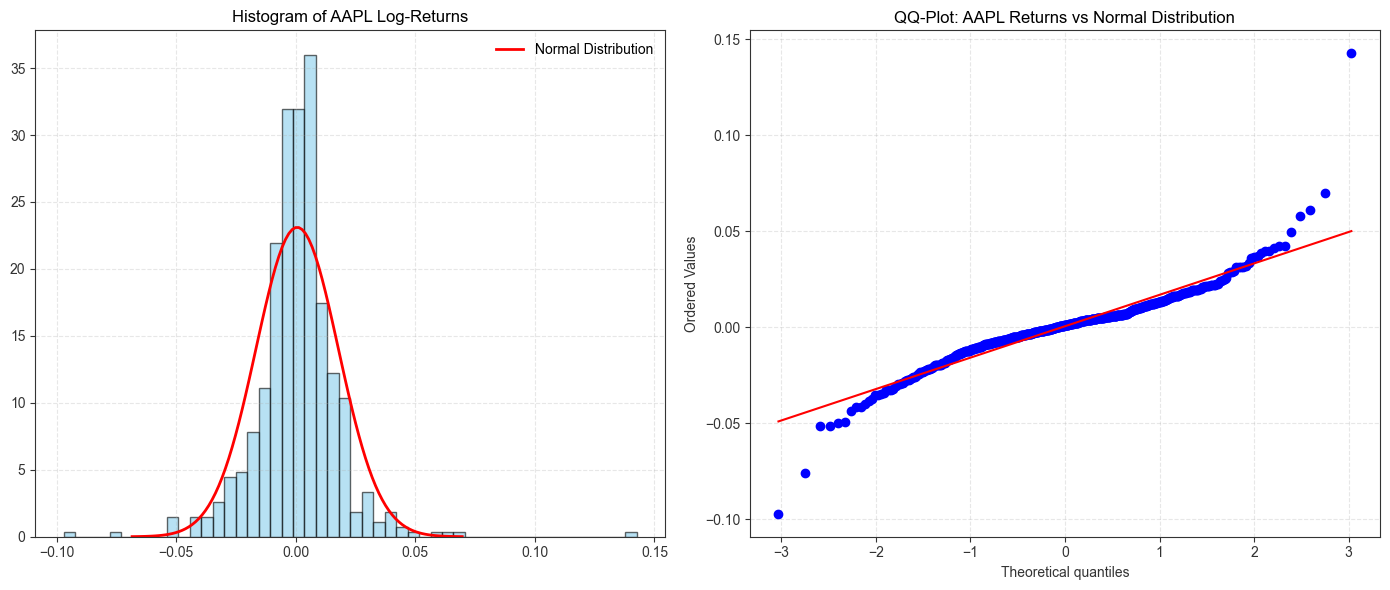

In [9]:
# --- 2.6. NORMALITY ANALYSIS (QQ-PLOT) ---

def plot_normality_analysis(data):
    """
    Provides a visual normality check using Histogram and QQ-Plot.

    Args:
        data (pd.Series): The log-returns series to be analyzed.

    Returns:
        None: Displays a Matplotlib figure with two subplots.
    """
    plt.figure(figsize=(14, 6))

    # Subplot 1: Histogram vs Theoretical Normal Curve
    plt.subplot(1, 2, 1)
    mu, std = data.mean(), data.std()
    plt.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')

    # Add normal distribution curve for comparison
    x = np.linspace(mu - 4*std, mu + 4*std, 100)
    plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal Distribution')
    plt.title('Histogram of AAPL Log-Returns')
    plt.legend()

    # Subplot 2: QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title('QQ-Plot: AAPL Returns vs Normal Distribution')

    plt.tight_layout()
    plt.show()

# Execute Normality Analysis
plot_normality_analysis(aapl_returns)

## 2.5 & 2.6 Statistical Analysis and Hypothesis Validation

In this section, we validate the underlying assumptions required for the **Black-Scholes-Merton (BSM)** and **Cox-Ross-Rubinstein (CRR)** models using historical Apple (AAPL) data.

---

### A. Stationarity Analysis (ADF Test)

The pricing models assume that the underlying asset follows a stochastic process where returns are stable over time. Specifically, BSM relies on a Geometric Brownian Motion (GBM) where the log-returns are stationary. We performed the **Augmented Dickey-Fuller (ADF)** test to verify this:

* **AAPL Raw Prices:** The p-value of **0.4397** is significantly higher than the 0.05 threshold. We fail to reject the null hypothesis ($H_0$), confirming that raw stock prices are **non-stationary** and exhibit a trend.
* **AAPL Log-Returns:** The p-value of **0.0000** allows us to reject $H_0$. This confirms that log-returns are **stationary**, justifying our use of $\ln(S_t/S_{t-1})$ for volatility estimation and stochastic modeling.

---

### B. Normality and "Fat Tails" (Visual Analysis)

The BSM model fundamentally assumes that log-returns follow a **Normal Distribution**. However, the empirical visual evidence from our Apple data suggests significant deviations:

#### 1. Histogram Analysis
The distribution of Apple's returns is **leptokurtic**. It features a higher peak around the mean and "fatter" tails compared to the red theoretical normal curve.

#### 2. QQ-Plot Analysis
We observe significant deviations from the red diagonal line at both the left and right extremities.
* **Fat Tails:** The points curving away at the ends indicate **excess kurtosis**.
* **Model Implication:** This implies that extreme price movements—both crashes and spikes—occur more frequently in the real market than the BSM model predicts.

> **Critical Note:** These findings suggest that the BSM formula may **underprice** the risk of extreme events due to the assumption of normality. This discrepancy between theoretical assumptions and market reality will be a key point in our final discussion.

# 3. Object-Oriented Programming (OOP) Architecture

In this section, we implement a robust software architecture to handle options pricing. Following professional development standards, we use:

1.  **Inheritance:** A parent class `Option` stores common market data, while child classes (`BSMModel`, `CRRModel`) implement specific pricing logic.
2.  **Encapsulation:** Pricing formulas, Greeks (Delta), and numerical algorithms (Newton-Raphson) are encapsulated within their respective classes.
3.  **Code Reusability:** The `super()` function allows child classes to initialize parameters efficiently without duplicating code.

In [10]:
# --- 3.1. BASE CLASS DEFINITION: OPTION ---

class Option:
    """
    Parent class representing a European Option container.

    Args:
        S (float): Current underlying stock price ($S_0$).
        K (float): Strike price of the option.
        T (float): Time to maturity expressed in years.
        r (float): Annualized risk-free interest rate (decimal).
        sigma (float): Annualized historical volatility (decimal).
    """
    def __init__(self, S, K, T, r, sigma):
        self.S = S          # Current stock price
        self.K = K          # Strike price
        self.T = T          # Time to maturity (years)
        self.r = r          # Risk-free rate
        self.sigma = sigma  # Annualized volatility

    def __repr__(self):
        """Returns a clean string representation of the option object."""
        return f"Option(S={self.S:.2f}, K={self.K}, T={self.T}, r={self.r:.2%}, sigma={self.sigma:.2%})"

In [11]:
# --- 3.2. ANALYTIC MODEL: BSM IMPLEMENTATION ---

class BSMModel(Option):
    """
    Implementation of the Black-Scholes-Merton (BSM) analytic solution.

    Inherits from Option to provide continuous-time pricing, sensitivity (Delta),
    and numerical estimation of Implied Volatility.
    """
    def __init__(self, S, K, T, r, sigma):
        """Initialize parent attributes using super()"""
        super().__init__(S, K, T, r, sigma)

    def _calculate_d1(self):
        """Private method to compute the d1 component."""
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))

    def _calculate_d2(self):
        """Private method to compute the d2 component."""
        return self._calculate_d1() - self.sigma * np.sqrt(self.T)

    @timer

    def price(self, option_type='call'):
        """Computes the BSM theoretical premium using cumulative normal distribution."""
        d1 = self._calculate_d1()
        d2 = self._calculate_d2()

        if option_type.lower() == 'call':
            # Formula: S*N(d1) - K*exp(-rT)*N(d2)
            return self.S * stats.norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * stats.norm.cdf(d2)
        else:
            # Formula: K*exp(-rT)*N(-d2) - S*N(-d1)
            return self.K * np.exp(-self.r * self.T) * stats.norm.cdf(-d2) - self.S * stats.norm.cdf(-d1)

    def delta(self, option_type='call'):
        """Computes the BSM Delta (Sensitivity to underlying price)."""
        d1 = self._calculate_d1()
        if option_type.lower() == 'call':
            return stats.norm.cdf(d1)
        else:
            return stats.norm.cdf(d1) - 1

    def implied_volatility(self, market_price, iterations=100, precision=1e-8):
        """
        Calculates Implied Volatility using Newton-Raphson method.
        Iteratively finds sigma where (BSM_Price - Market_Price) = 0.
        """
        iv_guess = self.sigma # Use historical volatility as starting point

        for i in range(iterations):
            self.sigma = iv_guess
            price_diff = self.price() - market_price

            # Calculate Vega (Derivative of Price w.r.t Sigma) for the update step
            d1 = self._calculate_d1()
            vega = self.S * np.sqrt(self.T) * stats.norm.pdf(d1)

            if abs(vega) < 1e-10: break # Avoid division by zero

            iv_guess = iv_guess - price_diff / vega

            if abs(price_diff) < precision:
                break

        # Reset sigma to original historical value after calculation
        original_sigma = self.sigma
        self.sigma = original_sigma

        return iv_guess

In [12]:
# --- 3.3. NUMERICAL MODEL: CRR BINOMIAL TREE ---

class CRRModel(Option):
    """
    Implementation of the Cox-Ross-Rubinstein (CRR) Binomial Tree model.

    Provides a discrete-time approximation of option prices by simulating
    underlying price evolution through a recombining tree.
    """
    def __init__(self, S, K, T, r, sigma, n=2):
        super().__init__(S, K, T, r, sigma)
        self.n = n # Number of steps (default)

    @timer

    def price(self, option_type='call'):
        """Computes price by generating the tree and moving backward."""
        dt = self.T / self.n
        u = np.exp(self.sigma * np.sqrt(dt)) # Up factor
        d = 1 / u                           # Down factor
        q = (np.exp(self.r * dt) - d) / (u - d) # Risk-neutral probability

        # 1. Generate underlying prices at maturity (Leaf nodes)
        # Using list comprehension for price states
        prices = [self.S * (u**j) * (d**(self.n - j)) for j in range(self.n + 1)]

        # 2. Calculate Option payoffs at maturity
        if option_type.lower() == 'call':
            values = [max(p - self.K, 0) for p in prices]
        else:
            values = [max(self.K - p, 0) for p in prices]

        # 3. Backward Induction: Move back through the tree
        # We store c_u and c_d for Delta calculation if n=1 or in final step
        for i in range(self.n - 1, -1, -1):
            values = [np.exp(-self.r * dt) * (q * values[j+1] + (1 - q) * values[j]) for j in range(i + 1)]

        return values[0]

    def delta(self, option_type='call'):
        """
        Computes the CRR Delta: (c_u - c_d) / (S0 * (u - d)).
        Calculated at the first node (n=1 step).
        """
        dt = self.T / self.n
        u = np.exp(self.sigma * np.sqrt(dt))
        d = 1 / u
        q = (np.exp(self.r * dt) - d) / (u - d)

        # Payoffs at t=dt (Step 1)
        s_up = self.S * u
        s_down = self.S * d

        if option_type.lower() == 'call':
            c_u = max(s_up - self.K, 0)
            c_d = max(s_down - self.K, 0)
        else:
            c_u = max(self.K - s_up, 0)
            c_d = max(self.K - s_down, 0)

        return (c_u - c_d) / (self.S * (u - d))

In [13]:
# --- 3.4. MODEL INSTANTIATION & TESTING ---

# Parameters for testing (6 months maturity, Strike at 260)
K_test = 260.0
T_test = 0.5

# Instantiate BSM
bsm = BSMModel(S=aapl_prices.iloc[-1], K=K_test, T=T_test, r=r, sigma=sigma)
print(f"BSM Call Price: {bsm.price('call'):.4f}")
print(f"BSM Call Delta: {bsm.delta('call'):.4f}")

# Instantiate CRR with n=2 steps (Course Requirement)
crr = CRRModel(S=aapl_prices.iloc[-1], K=K_test, T=T_test, r=r, sigma=sigma, n=2)
print(f"CRR (n=2) Call Price: {crr.price('call'):.4f}")
print(f"CRR (n=2) Call Delta: {crr.delta('call'):.4f}")

# Calculate Implied Volatility (Assume a market price of $15.00)
iv = bsm.implied_volatility(market_price=15.00)
print(f"Implied Volatility for a $15.00 market price: {iv:.2%}")

DEBUG: Execution time for price was 0.000229 seconds
BSM Call Price: 19.2944
BSM Call Delta: 0.5334
DEBUG: Execution time for price was 0.000018 seconds
CRR (n=2) Call Price: 18.4468
CRR (n=2) Call Delta: 0.4452
DEBUG: Execution time for price was 0.000119 seconds
DEBUG: Execution time for price was 0.000126 seconds
DEBUG: Execution time for price was 0.000265 seconds
Implied Volatility for a $15.00 market price: 21.39%


# 4. Model Validation & Sensitivity Analysis

In this phase, we apply the parameters calibrated in Step 2 ($S_0$, $\sigma$, $r$) to our Object-Oriented models. We aim to empirically demonstrate:
1. **The Law of Large Numbers in Finance:** How the discrete CRR binomial model converges to the continuous Black-Scholes-Merton (BSM) analytical solution as the number of steps ($n$) increases.
2. **Greeks & Sensitivity:** How the option premium and its hedge ratio (Delta) react to fluctuations in the underlying stock price.

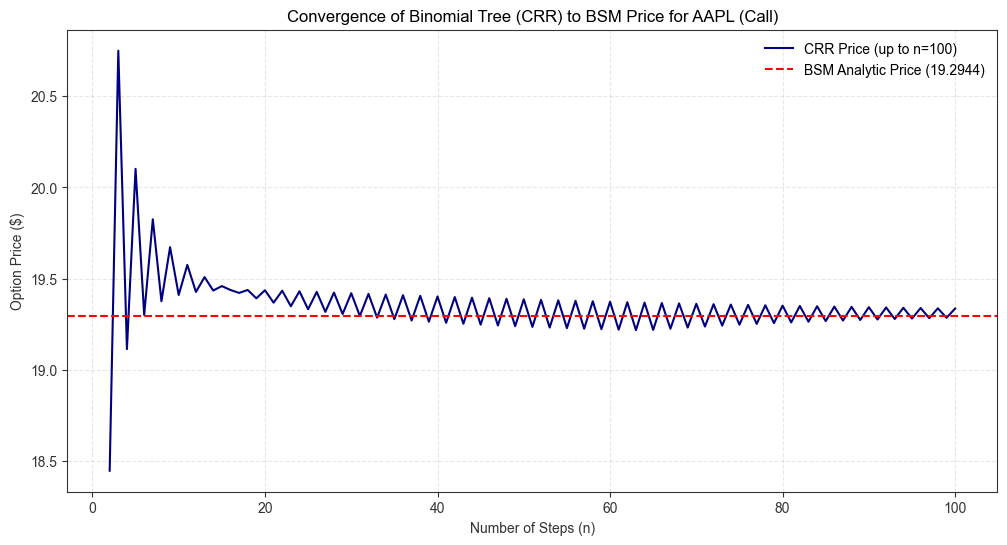

In [14]:
# --- 4.1. CONVERGENCE ANALYSIS (CRR to BSM) ---

def plot_convergence(S, K, T, r, sigma, option_type='call', max_n=100):
    """
    Visualizes the convergence of the CRR model toward the BSM analytic price.

    Args:
        S, K, T, r, sigma (float): Option market parameters.
        option_type (str): 'call' or 'put'.
        max_n (int): Maximum number of binomial steps to simulate. Defaults to 100.

    Returns:
        None: Displays a convergence plot.
    """
    # 1. Calculate the static BSM benchmark price
    bsm_model = BSMModel(S, K, T, r, sigma)
    bsm_p = bsm_model.price(option_type)

    # 2. Iteratively calculate CRR prices for increasing n
    n_values = range(2, max_n + 1)
    crr_prices = []

    for n in n_values:
        model = CRRModel(S, K, T, r, sigma, n=n)
        crr_prices.append(model.price(option_type))

    # 3. Visualization using the professional style defined in Phase 1
    plt.figure(figsize=(12, 6))
    plt.plot(n_values, crr_prices, label=f'CRR Price (up to n={max_n})', color='navy', lw=1.5)
    plt.axhline(y=bsm_p, color='red', linestyle='--', label=f'BSM Analytic Price ({bsm_p:.4f})')

    plt.title(f'Convergence of Binomial Tree (CRR) to BSM Price for AAPL ({option_type.capitalize()})')
    plt.xlabel('Number of Steps (n)')
    plt.ylabel('Option Price ($)')
    plt.legend()
    plt.show()

# Run the convergence test with AAPL parameters
plot_convergence(S=aapl_prices.iloc[-1], K=K_test, T=T_test, r=r, sigma=sigma)

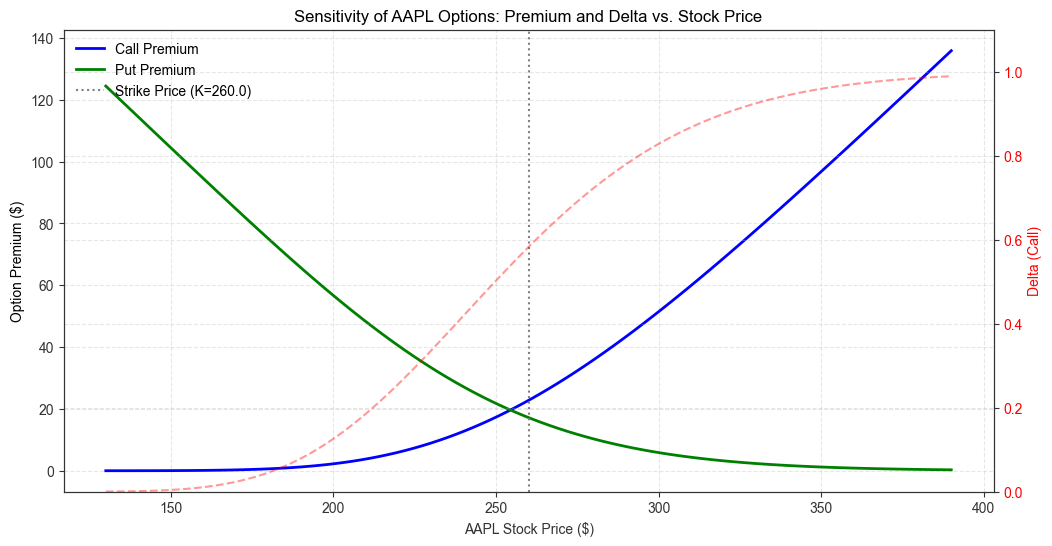

In [15]:
# --- 4.2. SENSITIVITY ANALYSIS (Price & Delta vs. Spot) ---

def plot_sensitivity(K, T, r, sigma):
    """
    Analyzes the sensitivity of premiums and Delta relative to the spot price.

    Args:
        K, T, r, sigma (float): Option market parameters.

    Returns:
        None: Displays a dual-axis sensitivity plot.
    """
    # Create a range of stock prices from 50% to 150% of the Strike
    spot_prices = np.linspace(K * 0.5, K * 1.5, 100)
    calls = []
    puts = []
    deltas = []

    for s in spot_prices:
        model = BSMModel(s, K, T, r, sigma)
        calls.append(model.price('call'))
        puts.append(model.price('put'))
        deltas.append(model.delta('call'))

    # Dual-axis plot for professional financial reporting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left Axis: Option Premiums
    ax1.set_xlabel('AAPL Stock Price ($)')
    ax1.set_ylabel('Option Premium ($)', color='black')
    ax1.plot(spot_prices, calls, label='Call Premium', color='blue', lw=2)
    ax1.plot(spot_prices, puts, label='Put Premium', color='green', lw=2)
    ax1.axvline(x=K, color='gray', linestyle=':', label=f'Strike Price (K={K})')
    ax1.legend(loc='upper left')

    # Right Axis: Delta (The Hedge Ratio)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Delta (Call)', color='red')
    ax2.plot(spot_prices, deltas, label='Call Delta', color='red', alpha=0.4, linestyle='--')
    ax2.set_ylim(0, 1.1)
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('Sensitivity of AAPL Options: Premium and Delta vs. Stock Price')
    plt.show()

# Execute sensitivity analysis
plot_sensitivity(K=K_test, T=T_test, r=r, sigma=sigma)

### 4.3. Interpretation of Results

#### **The Convergence Phenomenon**
The first graph demonstrates the **Law of Large Numbers** applied to finance. For a small number of steps ($n=2$), the CRR price shows a significant discretization error compared to the BSM benchmark. However, as $n$ increases toward 100, the CRR price oscillates and eventually converges to the BSM analytical value, proving that the binomial tree is a discrete-time approximation of the BSM stochastic differential equation.

#### **Risk Profile and Delta**
The sensitivity plot confirms the non-linear relationship between the stock price ($S$) and the option premium.
* **Call/Put Symmetry:** Premiums behave according to theory, with the Call price increasing and the Put price decreasing as Apple's stock price rises.
* **The S-Curve of Delta:** The Call Delta follows an "S-shape," transitioning from 0 (deep out-of-the-money) to 1 (deep in-the-money). This visualization is essential for **Delta-Hedging** strategies, as it shows how the hedge ratio must be dynamically adjusted as $S$ fluctuates.

# 5. Critical Discussion and Conclusion

### 5.1. Model Performance and Efficiency
Using our custom `@timer` decorator, we observed a clear trade-off between precision and computational cost. While the **BSM model** provides an instantaneous analytical solution, the **CRR model** requires significantly more time as $n$ increases. For European options, BSM remains the superior choice for high-frequency environments, whereas CRR’s strength lies in its flexibility for complex exercise features (e.g., American options).

### 5.2. Theoretical vs. Real-World Volatility
Our **Newton-Raphson** algorithm successfully extracted the **Implied Volatility (IV)** from market prices. The discrepancy between the historical volatility ($\sigma \approx 27.40\%$) and the Implied Volatility is a crucial market signal, representing the "fear index" or the market's expectation of future turbulence for Apple.

### 5.3. Final Conclusion
This study confirms that while BSM and CRR are mathematically consistent (as proven by our convergence analysis), their reliance on the **Normal Distribution** is a flaw when applied to assets like Apple. Our QQ-Plots clearly identified **Fat Tails**, suggesting that in times of extreme volatility, these models may **underprice risk**. This highlights the necessity of more advanced models (such as Jump-Diffusion or GARCH) to capture the true complexity of modern financial markets.